# Part I: Building the Model
In this model, photons enter the top of a homogenous absorbing atmosphere and travel downward toward the surface. In this case, each photon either reaches the surface or is extinguished. 

The probability that a photon survives through optical depth $\tau$ without extinction is
$$
P(\tau) = e^{-\tau}.
$$

The cumulative distribution function for extinction optical depth is therefore

$$
CDF(\tau) = 1 - e^{-\tau}.
$$

To get the optical depth traveled by each photon, we can draw a random number $\zeta$ from a uniform distribution between 0 and 1 and apply sampling methods to get:

$$
\tau_s = -\ln(1-\zeta).
$$

Here, $\tau_s$ is the sampled optical depth traveled by the photon before extinction. For a solar zenith angle $\theta$, the angled optical depth required to reach the surface is

$$
\tau_{\mathrm{surface}} = \frac{\tau^*}{\mu},
$$

where ${\tau^*}$ is the total optical depth for the atmosphere and where 

$$
\mu = \cos\theta.
$$

A photon reaches the surface if

$$
\tau_s \geq \tau_{\mathrm{surface}}.
$$

Therefore, the Monte Carlo estimate of direct surface transmittance is:

$$
T_{\mathrm{MC}} = \frac{N_{\mathrm{survived}}}{N_{\mathrm{total}}}.
$$

The following code applies this to a model and creates a plot of fractional photon survival with atmospheric height, using the calculated optical depth values for set conditions. 

For an optical depth of 0.25, solar zenith angle of 82 degrees, and atmospheric thickness of 100.000 km:
Fraction of photons reaching the surface: 0.779
Fraction of photons extinguished: 0.221
Mean path length: 2867.585
Transmittance: 0.166


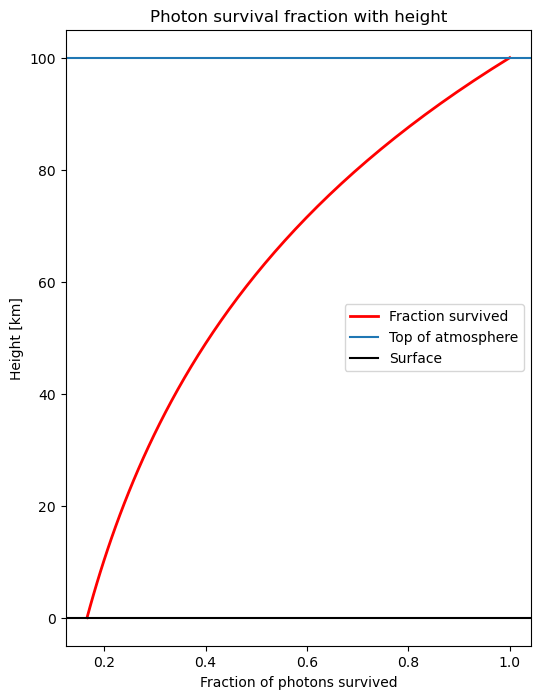

0.13917310096006547


In [16]:
import numpy as np
import matplotlib.pyplot as plt

#-----------------------
# constants
Zatm = 100 # arbitrary value (troposphere thickness) [km]
theta = 82
theta_rad = np.deg2rad(theta)
mu = np.cos(theta_rad) # set solar zenith angle theta
TOD = .25 # set total optical depth
N = 100000 # number of photons

#-----------------------
# individual photon optical depths
rand_array = np.random.rand(N) # sampled optical depth for N number of photons
tau = -np.log(1-rand_array)

#-----------------------
# outcome
tau_surface = TOD / mu
yes = tau >= tau_surface
no = tau < tau_surface

# path length
L = (Zatm*tau)/(mu*TOD)

# statistics
yays = np.mean(yes)
nays = np.mean(no)

# optical depth required
z_vals = np.linspace(0, Zatm, 50)
tau_req = (TOD/mu) * (1-z_vals/Zatm)
survived = np.exp(-tau_req)
transmit = survived[0]

print(f"For an optical depth of {TOD:.2f}, solar zenith angle of {theta:.0f} degrees, and atmospheric thickness of {Zatm:.3f} km:")
print(f"Fraction of photons reaching the surface: {yays:.3f}")
print(f"Fraction of photons extinguished: {nays:.3f}")
print(f"Mean path length: {np.mean(L):.3f}")
print(f"Transmittance: {transmit:.3f}")

# plot
plt.figure(figsize=(6, 8))
dz = z_vals[1] - z_vals[0]
plt.plot(survived, z_vals, 'r-', linewidth=2, label="Fraction survived")
plt.axhline(100,label="Top of atmosphere")
plt.axhline(0,color='k',label="Surface")
plt.xlabel("Fraction of photons survived")
plt.ylabel("Height [km]")
plt.title("Photon survival fraction with height")
plt.legend()
plt.show()

tau_efold = -mu * np.log(1/np.e)
print(tau_efold)

## AI USAGE
Tool: Visual Studio Code AI helper
Provided suggestions for coding and setting up the plot

# Part II: Model Verification


## Verification Test #1

Expected behavior:
Using inverse-transform sampling,

$$
\tau_s = -\ln(1-\zeta),
$$

should produce sampled optical depths with probability density

$$
p(\tau_s) = e^{-\tau_s},
$$

where the mean sampled optical depth should be ~ 1.

To verify this, we can generate a large number of sampled optical depths and compare their histogram with the plotted exponential probability density. If the model is sampling extinction distances correctly, the Monte Carlo histogram should closely follow $e^{-\tau_s}$ and the mean sampled optical depth should be close to 1.


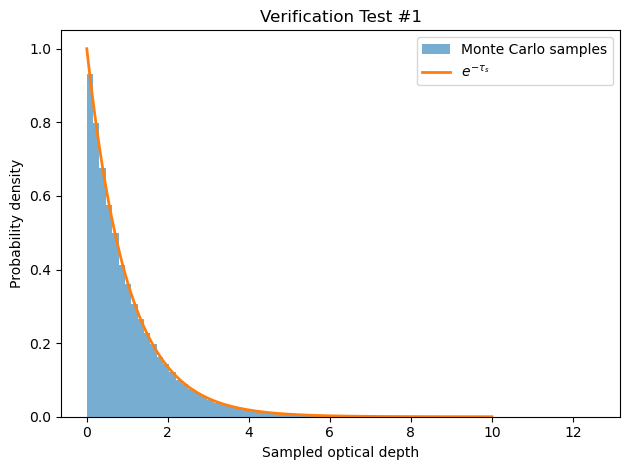

Mean sampled optical depth: 0.995091687098452


In [17]:
rng = np.random.default_rng(100)
tau_samples = rng.exponential(scale=1.0, size=N)
taus = np.linspace(0, 10, 300)
prob = np.exp(-taus)
plt.figure()
plt.hist(tau_samples, bins=80, density=True, alpha=0.6, label="Monte Carlo samples")
plt.plot(taus, prob, linewidth=2, label=r"$e^{-\tau_s}$")
plt.xlabel("Sampled optical depth")
plt.ylabel("Probability density")
plt.title("Verification Test #1")
plt.legend()
plt.tight_layout()
plt.show()
print("Mean sampled optical depth:", tau_samples.mean())

### Results:
Shown above, the plotted samples of optical depth in histogram form closely follows the analytical exponential distribution curve. The sampled mean, shown below the plot, is also close to 1, which is the expected mean of an exponential distribution. Since our results align with the expected outcome, we can verify that the model correctly samples optical depths. 

## Verification Test #2

Expected behavior:
The Monte Carlo model should behave correctly in limiting cases. If the atmosphere has zero optical depth,

$$
\tau^* = 0,
$$

then there is no absorption and every photon should reach the surface. Therefore, the expected transmittance is

$$
T = 1.
$$

If the optical depth is very large, the atmosphere should become nearly opaque, so almost no photons should reach the surface. Therefore the transmittance should tend to 0. 

To verify this, we can run the Monte Carlo model for $\tau^*=0$ and large values. We can then check what the transmittance tends to. 

In [18]:
tau_test = [0, 10] 

for TOD in tau_test:
    tau_sample = rng.exponential(scale=1.0, size=N)
    tau_to_surface = TOD / mu
    survived = tau_sample >= tau_to_surface
    T_mc = survived.mean()
    print(f"for tau = {TOD}, transmittance = {T_mc:.6f}")

for tau = 0, transmittance = 1.000000
for tau = 10, transmittance = 0.000000


### Results:
 
This test executed above shows that the Monte Carlo model behaves physically correctly. When $\tau^*=0$, the atmosphere has no absorbing optical depth, so every photon reaches the surface and the Monte Carlo transmittance is approximately 1.

When the optical depth is large, or with $\tau^*=10$, the atmosphere is optically thick. Almost all photons are absorbed before reaching the surface, so the Monte Carlo transmittance is close to zero.


# Part III: Radiative Transfer Experiments

### 1.

For the sun directly overhead, where $$\theta = 0^\circ,$$ so $$\mu = \cos(0^\circ) = 1.$$

An e-folding reduction means that the surface intensity is reduced to $$\frac{1}{e}.$$ Therefore, $$T = e^{-1} \approx 0.368.$$

Using the direct-beam transmittance equation,

$$
T = \exp(-\frac{\tau^*}{\mu}),
$$

and substituting $\mu = 1$ gives

$$
T = e^{-\tau^*}.
$$

For an e-folding reduction,

$$
e^{-\tau^*} = e^{-1}.
$$

Therfore, the optical depth that produces an e-folding reduction in surface intensity for overhead sun is

$$
{\tau^* = 1}.
$$

The Monte Carlo simulation should therefore give a surface transmittance close to 0.368 for this case.

In [29]:
# Part III Q1 abbreviated model
theta_q1 = 0
mu_q1 = np.cos(np.deg2rad(theta_q1))
tau_q1 = 1

tau_sample = rng.exponential(scale=1.0, size=N)
T_q1 = np.mean(tau_sample >= tau_q1/mu_q1)

print("Q1 transmittance:", T_q1)

Q1 transmittance: 0.37196


### 2.

For a solar zenith angle of

$$
\theta = 60^\circ,
$$

the cosine factor is

$$
\mu = \cos(60^\circ) = 0.5.
$$

Using

$$
T = \exp\left(-\frac{\tau^*}{\mu}\right),
$$

with $\tau^* = 1$ gives

$$
T = \exp(-\frac{1}{0.5}).
$$

So,

$$
T = e^{-2} \approx 0.135.
$$

Therefore, for $\tau^* = 1$ and $\theta = 60^\circ$, the direct surface transmittance is

$$
{T \approx 0.135}.
$$

This means that about 13.5% of the photons reach the surface. The transmittance is lower because of the angled path through the atmosphere.

In [30]:
# Q2 abbrev. model
theta_q2 = 60
mu_q2 = np.cos(np.deg2rad(theta_q2))
tau_q2 = 1

tau_sample = rng.exponential(scale=1.0, size=N)
T_q2 = np.mean(tau_sample >= tau_q2/mu_q2)

print("Q2 transmittance:", T_q2)

Q2 transmittance: 0.13462


### 3. 

As the sun approaches the horizon,

$$
\theta \rightarrow 90^\circ.
$$

Therefore,

$$
\mu = \cos\theta = 0.
$$

The effective optical depth is

$$
\tau = \frac{\tau^*}{\mu}.
$$

As $\mu$ approaches zero, that optical depth becomes large as 

$$
\frac{\tau^*}{\mu} \rightarrow \infty.
$$

So, the direct-beam transmittance becomes

$$
T = \exp(-\frac{\tau^*}{\mu}) \rightarrow 0.
$$

Therefore, in an absorbing atmosphere, the surface becomes dark when the sun reaches the horizon because the direct solar beam travels through an extremely long atmospheric path. This makes the optical depth very large, so nearly all photons are absorbed before reaching the surface.

### 4. 

To examine how transmittance changes with height, we can use the model, which calculates the fraction of photons that survive at different heights in the atmosphere. The optical depth accumulated from the top of the atmosphere down to a height is proportional to the fraction of atmosphere above that height:

$$
\tau(z) = \tau^*(1 - z/H).
$$

For overhead sun, $\mu=1$, so the transmittance is

$$
T(z) = \exp[-\tau^*(1-z/H)].
$$

The additional code below overlays the plots for depths of 1, 3, and 10 into one figure to visualize the results.

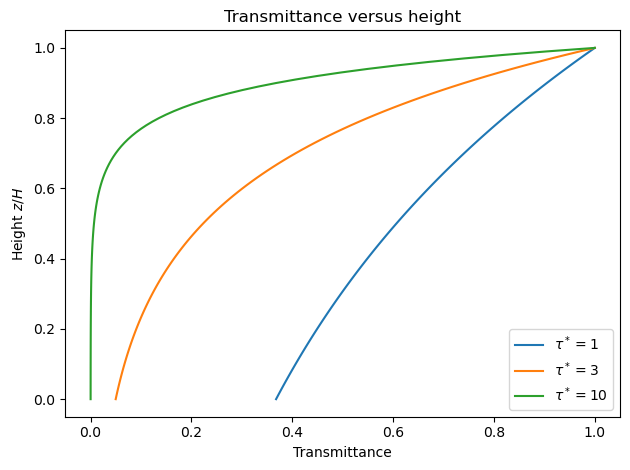

In [32]:
def transmittance_profile_mc(tau_total, theta_deg=0, N=200000):
    mu = np.cos(np.deg2rad(theta_deg))
    z_over_H = np.linspace(0, 1, nlevels)
    tau_to_level = tau_total*(1 - z_over_H)/mu
    tau_sample = rng.exponential(scale=1.0, size=N)
    T = np.array([np.mean(tau_sample >= tau_level) for tau_level in tau_to_level])
    return z_over_H, T
plt.figure()
for TOD in [1, 3, 10]:
    z, T = transmittance_profile(TOD, theta_deg=0)
    plt.plot(T, z, label=rf"$\tau^*={TOD}$")
plt.xlabel("Transmittance")
plt.ylabel(r"Height $z/H$")
plt.title("Transmittance versus height")
plt.legend()
plt.tight_layout()
plt.show()

The transmittance decreases downward through the atmosphere because photons accumulate more absorbing optical depth along the path. The $\tau^*$
=1 atmosphere remains transparent, with about 37% of direct photons reaching the surface. The $\tau^*$=3 atmosphere is much more absorbing, with only about 5% reaching the surface. The $\tau^*$=10 atmosphere is completely absorbed by z/H = 0.4.

# Part IV: AERONET

### Introduction

In this section, we apply AERONET aerosol optical depth data to estimate direct surface transmittance for a real atmosphere. The measured quantities from the database are are the aerosol optical depth at 500 nm and the evolving solar zenith angle.

As before, the direct-beam transmittance is estimated using

$$
T = \exp(-\frac{\tau}{\cos\theta}),
$$

where $\tau$ is the measured aerosol optical depth and $\theta$ is the solar zenith angle.

### Methods

I selected the La Jolla AERONET station, applicable to our location at UCSD, and used Level 2.0 aerosol optical depth data for a day with noticeable aerosol variability. From the downloaded dataset, we can extract the 500 nm aerosol optical depth and the solar zenith angle columns.

The code reads the AERONET data file, removes missing values, and stores the measured optical depth and solar zenith angle. The direct transmittance is then calculated and displayed in three ways using the basis from our created model:

1. Variable

$$
T_{\mathrm{measured}}(t) = \exp\left[-\frac{\tau(t)}{\cos\theta(t)}\right]
$$

2. Constant Optical Depth
$$
T_{\mathrm{constant}\ \tau}(t) = \exp\left[-\frac{\overline{\tau}}{\cos\theta(t)}\right]
$$

3. Constant Solar Zenith Angle

$$
T_{\mathrm{constant}\ \theta}(t) = \exp\left[-\frac{\tau(t)}{\cos\theta_{\min}}\right]
$$

Comparing these curves can directly show whether changes in optical depth or changes in solar zenith angle are more responsible for the estimated changes in surface transmittance.

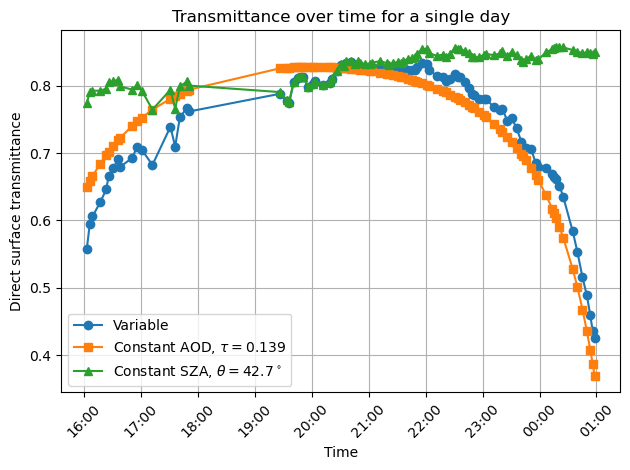

In [20]:
import pandas as pd
import matplotlib.dates as mdates

# load aeronet file
df = pd.read_csv("20200223_20200223_La_Jolla.lev20", skiprows=6)

# extract columns
aod_col = "AOD_500nm"
sza_col = "Solar_Zenith_Angle(Degrees)"
time_col = "Time(hh:mm:ss)"

# convert variables to numeric digits
df[aod_col] = pd.to_numeric(df[aod_col], errors="coerce")
df[sza_col] = pd.to_numeric(df[sza_col], errors="coerce")


# Extract variables
tau = df[aod_col].values
theta = df[sza_col].values
t = pd.to_datetime(df[time_col], format="%H:%M:%S", errors="coerce")
date0 = pd.Timestamp("2020-02-23")
t = date0 + pd.to_timedelta(t.dt.strftime("%H:%M:%S"))

# show past midnight
t_shifted = t.copy()
t_shifted[t_shifted < t_shifted.iloc[0]] += pd.Timedelta(days=1)
mu = np.cos(np.deg2rad(theta))

# keep valid cases with sun above horizon
valid = mu > 0
tau = tau[valid]
theta = theta[valid]
mu = mu[valid]
t = t[valid]

# calc transmittance
T_actual = np.exp(-tau / mu)

# constant tau
tau_mean = np.mean(tau)
T_constant_tau = np.exp(-tau_mean / mu)

# constant theta
theta_fixed = np.min(theta)
mu_fixed = np.cos(np.deg2rad(theta_fixed))
T_constant_theta = np.exp(-tau / mu_fixed)

# plot
plt.figure()
plt.plot(t_shifted, T_actual, marker="o", label="Variable")
plt.plot(t_shifted, T_constant_tau, marker="s", label=rf"Constant AOD, $\tau={tau_mean:.3f}$")
plt.plot(t_shifted, T_constant_theta, marker="^", label=rf"Constant SZA, $\theta={theta_fixed:.1f}^\circ$")
plt.xlabel("Time")
plt.ylabel("Direct surface transmittance")
plt.title("Transmittance over time for a single day")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Results

For the La Jolla station on the selected day, the 500 nm aerosol optical depth varied from approximately 0.18 to 0.12 over the analyzed period. The solar zenith angle changed more strongly, decreasing from about $71^\circ$ to a minimum of about $41.7^\circ$, then increasing again to about $82^\circ$. The time interestingly is recorded from 16:00 to 01:00, which may be recorded in Zulu time (UTC) instead of PST. 

The likely dominant aerosol source at this coastal station is marine aerosol, especially sea salt. Local pollution may also contribute, but the marine environment off the La Jolla coast is the most likely background source.

Using the relation mentioned above, the estimated surface transmittance changes substantially throughout the day. Early in the period, when $\tau \approx 0.18$ and $\theta \approx 71^\circ$,

$$
T \approx \exp(-\frac{0.18}{\cos 71^\circ}) \approx 0.575.
$$

Near the smallest solar zenith angle, the sun is highest in the sky and the atmospheric path length is shortest. This increases the direct transmittance. Later, even though the AOD is lower, the solar zenith angle becomes much larger, which increases the path length and reduces direct transmittance.

The constant-$\tau$ calculation and plot above shows how transmittance changes if aerosol optical depth is fixed at the daily mean value while solar zenith angle changes. This curve changes strongly throughout the day, showing that solar geometry alone has a impactful effect on direct transmittance.

The constant-$\theta$ calculation shows how transmittance changes if the solar zenith angle is fixed while AOD changes. This curve varies much less than the constant-$\tau$ curve, showing that the observed AOD changes have a smaller effect than the solar zenith angle changes for this particular day.

In Conclusion, for this La Jolla case, solar zenith angle appears to be the dominant factor affecting the estimated direct surface transmittance. AOD matters, but the change in $\theta$ produces a larger difference.

# Part V: Investigation

### Question
How does idealized direct UV transmittance compare with direct transmittance at 500 nm for the same solar zenith angle conditions?

### Hypothesis
Because UV optical depth is larger than 500 nm optical depth, the direct UV transmittance should be lower than the 500 nm transmittance. However, both wavelength ranges should follow the same general solar-zenith-angle trend.

### Experiment 

The experiment compares direct transmittance for two wavelength ranges:

1. 500 nm visible radiation
2. UV radiation at 340 nm

For each observation time, the model calculates

$$
T = \exp(-\frac{\tau}{\cos\theta})
$$

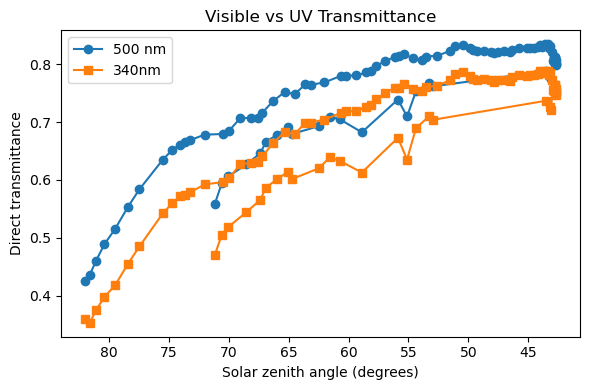

In [21]:
# UV AOD column
uv_col = "AOD_340nm"  
df[uv_col] = pd.to_numeric(df[uv_col], errors="coerce")

# clean nan values
df_uv = df.replace(-999, np.nan).dropna(subset=[aod_col, uv_col, sza_col, time_col])

# extract
tau_500 = df_uv[aod_col].values
tau_uv = df_uv[uv_col].values
theta_uv = df_uv[sza_col].values
mu_uv = np.cos(np.deg2rad(theta_uv))

# calculate transmittance
T_500 = np.exp(-tau_500/mu_uv)
T_uv = np.exp(-tau_uv/mu_uv)

# plot
plt.figure(figsize=(6,4))
plt.plot(theta_uv, T_500, marker="o", label="500 nm")
plt.plot(theta_uv, T_uv, marker="s", label=uv_col.replace("AOD_", ""))
plt.gca().invert_xaxis()
plt.xlabel("Solar zenith angle (degrees)")
plt.ylabel("Direct transmittance")
plt.title("Visible vs UV Transmittance")
plt.legend()
plt.tight_layout()
plt.show()

### Results

The plot supports that direct UV transmittance is consistently lower than 500 nm transmittance as the UV optical depth is consistently larger than the 500 nm optical depth. 

Both the UV and 500 nm curves follow the same pattern, with no discrepancies or outliers.

These results were expected but show that optical depth can indeed set an influential scale with radiation wavelength, as well as being heavily influenced by the solar zenith angle. 

# AI Usage Statement

Tool: Claude and Visual Studio Code's AI helper.

Prompts: AI tools were used to help debug Python code, brainstorm investigation ideas, create code to extract values directly from the AERONET dataset, and were finally used to ensure the assignment fulfills the instructions.

How it was used: AI suggestions helped brainstorm how to present the photon survival model, plot the results and develop equations for constant AOD vs constant SZA transmittance comparisons, and improve the wording of the AERONET and investigation results. The final code and writing was ran through claude to ensure validity, consistency, and clarity. 
